# Classical Baseline Assumptions

This notebook separates what the classical benchmark helpers actually time from what the QSVT proxy reports estimate. The examples are small by design: they are assumption checks, not performance claims.

## Setup

Dense solves, conjugate gradients, dense spectral matrix functions, and polynomial matrix evaluation all start from different access assumptions. The benchmark helpers keep those assumptions explicit in each JSON-style report.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
from qsvt.benchmarks import (
    benchmark_summary_table,
    conjugate_gradient_benchmark,
    dense_linear_solve_benchmark,
    plot_benchmark_timings,
    plot_qsvt_proxy_resources,
    polynomial_matrix_function_benchmark,
    spectral_matrix_function_benchmark,
)
from qsvt.design import design_positive_inverse_polynomial
from qsvt.matrices import diagonal_matrix

CASE_LABELS = {
    "numpy.linalg.solve": "DLS",
    "qsvt.benchmarks.conjugate_gradient_solve": "CGS",
    "dense-spectral-matrix-function": "DSMF",
    "spectral-polynomial-evaluation": "PME",
}


def case_label(row):
    return CASE_LABELS.get(row["algorithm"], row["algorithm"])


def fmt(value):
    if value is None:
        return "n/a"
    if isinstance(value, float):
        if value == 0.0:
            return "0"
        if abs(value) < 1e-3 or abs(value) >= 1e4:
            return f"{value:.2e}"
        return f"{value:.4g}"
    return str(value)


def display_table(title, rows, columns):
    rendered = [
        [str(name) for name, _ in columns],
        *[[fmt(getter(row)) for _, getter in columns] for row in rows],
    ]
    widths = [max(len(row[index]) for row in rendered) for index in range(len(columns))]
    print(title)
    print("=" * len(title))
    print(
        "  ".join(
            value.ljust(width) for value, width in zip(rendered[0], widths, strict=True)
        )
    )
    print("  ".join("-" * width for width in widths))
    for row in rendered[1:]:
        print(
            "  ".join(
                value.ljust(width) for value, width in zip(row, widths, strict=True)
            )
        )

## Linear-System Assumptions

The dense solve times a full direct solve. The CG baseline reports iteration diagnostics but still uses dense NumPy matrix-vector products in this educational implementation.

In [2]:
dimension = 8
diag = np.linspace(0.25, 1.0, dimension)
matrix = diagonal_matrix(diag)
rhs = np.linspace(1.0, 2.0, dimension)
coeffs = design_positive_inverse_polynomial(gamma=diag.min(), degree=9, num_points=401)

dense_report = dense_linear_solve_benchmark(matrix, rhs, repeats=1, qsvt_coeffs=coeffs)
cg_report = conjugate_gradient_benchmark(matrix, rhs, repeats=1, qsvt_coeffs=coeffs)
linear_reports = [dense_report, cg_report]
linear_rows = benchmark_summary_table(linear_reports)

In [3]:
display_table(
    "Linear-system baseline readout",
    linear_rows,
    [
        ("Case", case_label),
        ("Classical algorithm", lambda row: row["algorithm"]),
        ("Condition", lambda row: row["condition_number_2"]),
        (
            "Relative residual",
            lambda row: row["relative_residual_norm"],
        ),
        ("QSVT degree [polynomial degree]", lambda row: row["polynomial_degree"]),
        (
            "Signal calls [operator calls]",
            lambda row: row["qsvt_signal_operator_calls"],
        ),
    ],
)

print()
print(
    "DLS times a dense direct solve. CGS reports iterative-solver diagnostics, "
    "but this educational benchmark still uses dense NumPy matrix-vector products."
)

Linear-system baseline readout
Case  Classical algorithm                       Condition  Relative residual  QSVT degree [polynomial degree]  Signal calls [operator calls]
----  ----------------------------------------  ---------  ---------------------------------  -------------------------------  -----------------------------
DLS   numpy.linalg.solve                        4          8.86e-17                           9                                9                            
CGS   qsvt.benchmarks.conjugate_gradient_solve  4          1.77e-16                           9                                9                            

DLS times a dense direct solve. CGS reports iterative-solver diagnostics, but this educational benchmark still uses dense NumPy matrix-vector products.


## Matrix-Function Assumptions

Dense spectral matrix functions time exact small-system functional calculus. Polynomial matrix evaluation applies the same polynomial transform that a QSVT sequence would encode, but by diagonalizing classically.

In [4]:
hamiltonian = diagonal_matrix(np.linspace(-1.0, 1.0, dimension))
filter_coeffs = np.array([0.5, 0.0, -0.5])

spectral_report = spectral_matrix_function_benchmark(
    hamiltonian,
    "exponential",
    repeats=1,
    beta=0.6,
)
polynomial_report = polynomial_matrix_function_benchmark(
    hamiltonian,
    filter_coeffs,
    repeats=1,
)
matrix_function_reports = [spectral_report, polynomial_report]
matrix_function_rows = benchmark_summary_table(matrix_function_reports)

display_table(
    "Matrix-function baseline readout",
    matrix_function_rows,
    [
        ("Case", case_label),
        ("Classical algorithm", lambda row: row["algorithm"]),
        ("QSVT degree [polynomial degree]", lambda row: row["polynomial_degree"]),
        (
            "Signal calls [operator calls]",
            lambda row: row["qsvt_signal_operator_calls"],
        ),
        ("Best time (s)", lambda row: row["best_time_seconds"]),
    ],
)

print()
print(
    "DSMF is the exact dense spectral reference. PME applies the supplied "
    "polynomial classically and is the closest fixed-polynomial comparison "
    "to a QSVT sequence."
)

Matrix-function baseline readout
Case  Classical algorithm             QSVT degree [polynomial degree]  Signal calls [operator calls]  Best time (s)
----  ------------------------------  -------------------------------  -----------------------------  -------------
DSMF  dense-spectral-matrix-function  n/a                              n/a                            1.35e-04     
PME   spectral-polynomial-evaluation  2                                2                              1.27e-04     

DSMF is the exact dense spectral reference. PME applies the supplied polynomial classically and is the closest fixed-polynomial comparison to a QSVT sequence.


## What Is Timed vs Proxied

The plots below use the shared benchmark plotting helpers. The x-axis uses compact numeric case positions, while the coloured legend names each case with short labels such as DLS, CGS, DSMF, and PME.

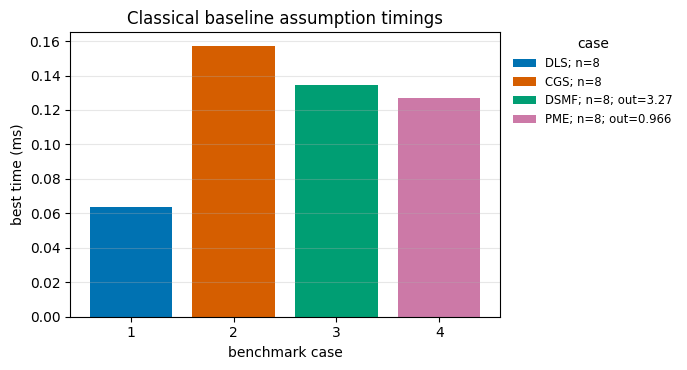

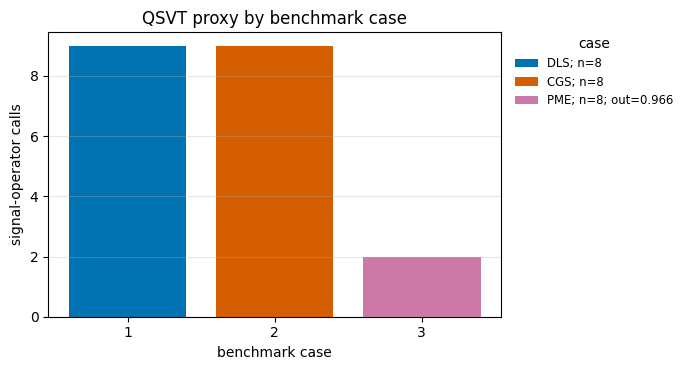

In [5]:
reports = [*linear_reports, *matrix_function_reports]

_ = plot_benchmark_timings(
    reports,
    title="Classical baseline assumption timings",
)
_ = plot_qsvt_proxy_resources(
    reports,
    title="QSVT proxy by benchmark case",
)

plt.show()